DRY RUN: generating 5 patterns
Generated 5 light patterns
Params: {'Km': np.float64(0.251188643150958), 'k12': np.float64(0.35481338923357547), 'k21': np.float64(0.11220184543019636), 'k34': np.float64(0.7079457843841379), 'knfb': np.float64(2.2387211385683394), 'k43': np.float64(0.03162277660168379), 'k56': np.float64(2.2387211385683394), 'k65': np.float64(0.31622776601683794), 'k78': np.float64(1.5848931924611136), 'k87': np.float64(0.14125375446227545), 'f12': np.float64(3.1622776601683795), 'f21': np.float64(0.7943282347242815)}


Simulating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 26.42it/s]


DataFrame: 5 rows, 11 columns
Saved to synthetic_EGFR_data_dry.parquet


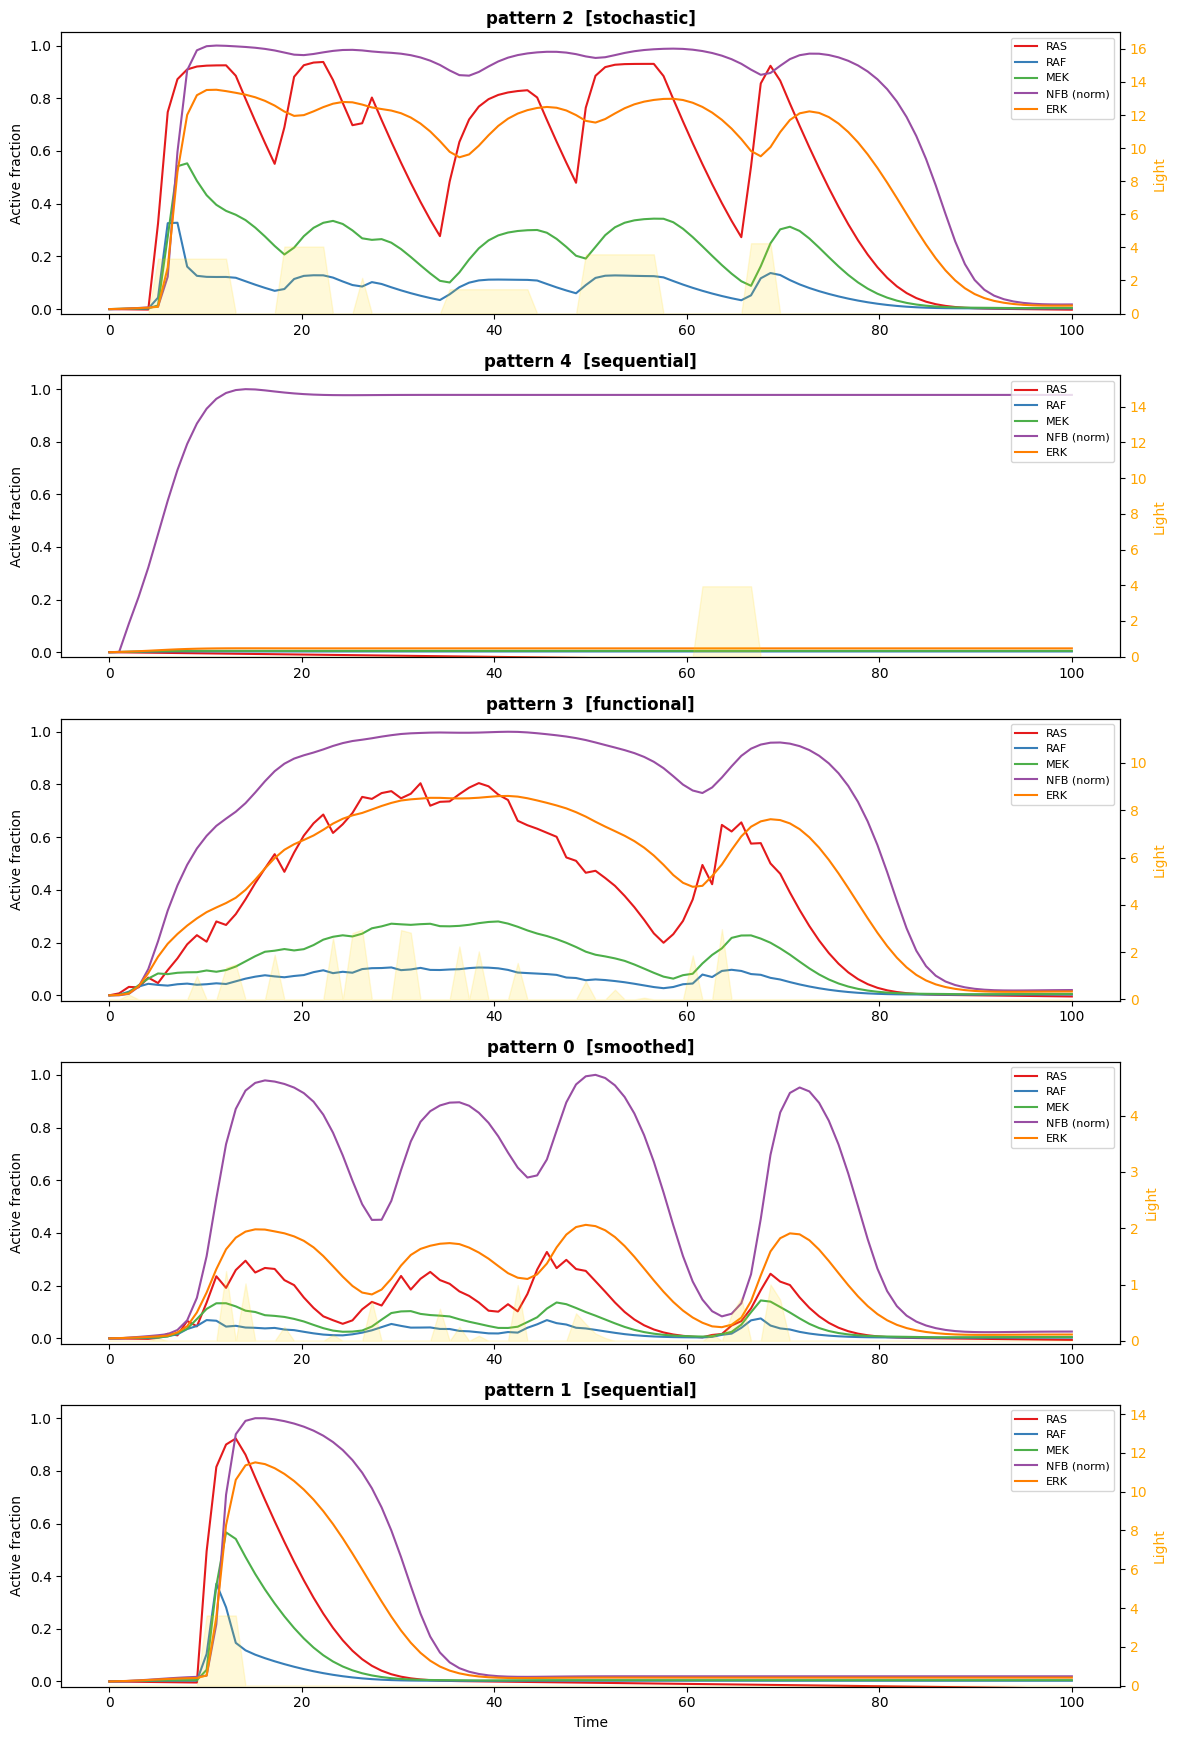

Plotted 5 sample trajectories


In [1]:
from generate_synthetic_data import *

n = 5 if DRY_RUN else N_TOTAL
print(f"{'DRY RUN' if DRY_RUN else 'FULL RUN'}: generating {n} patterns")

patterns = generate_all_patterns(n, seed=SEED)
print(f"Generated {len(patterns)} light patterns")

system = build_system()
params_vec = load_params(PARAMS_PATH)
print(f"Params: {dict(zip(PARAM_NAMES, params_vec))}")

df = build_dataframe(patterns, system, params_vec)
print(f"DataFrame: {df.shape[0]} rows, {df.shape[1]} columns")

out = OUTPUT_PATH if not DRY_RUN else "synthetic_EGFR_data_dry.parquet"
df.to_parquet(out, index=False)
print(f"Saved to {out}")

plot_sample_trajectories(df, n=min(5, len(df)))

# Read and plot things

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


synth_data = pd.read_parquet('synthetic_EGFR_data.parquet')

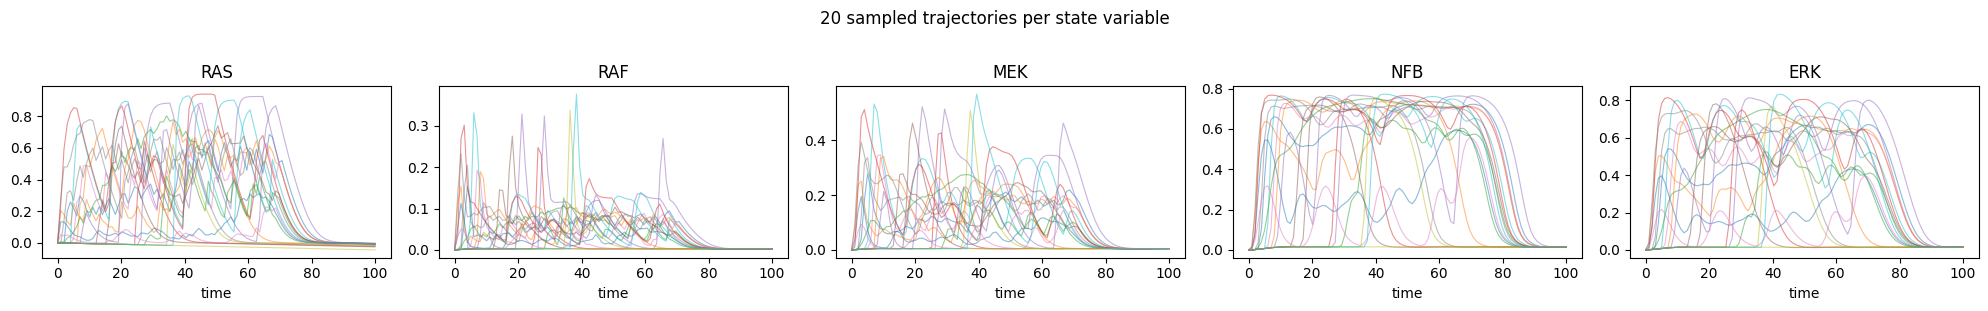

In [4]:

N_SAMPLE = 20 
STATE_COLS = ["RAS_s", "RAF_s", "MEK_s", "NFB_s", "ERK_s"]

sample = synth_data.sample(N_SAMPLE, random_state=42)

fig, axes = plt.subplots(1, len(STATE_COLS), figsize=(4 * len(STATE_COLS), 3), sharey=False)
for ax, col in zip(axes, STATE_COLS):
    for _, row in sample.iterrows():
        ts = np.array(row["times"])
        ys = np.array(row[col])
        ax.plot(ts, ys, alpha=0.5, linewidth=0.8)
    ax.set_title(col.replace("_s", ""))
    ax.set_xlabel("time")
fig.suptitle(f"{N_SAMPLE} sampled trajectories per state variable", y=1.02)
fig.tight_layout()
plt.show()